![](img/330-banner.png)

In [ ]:
# Montar el google drive

from google.colab import drive
drive.mount('/content/drive')

## Imports

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.compose import ColumnTransformer, make_column_transformer

# Escriba el nombre de los paquetes que requiera para realizar los ejer

## K-Means caso de estudio: Segmentación de clientes

A menudo es beneficioso para las empresas explorar el panorama del mercado y adaptar sus servicios y productos ofrecidos a cada grupo. Esto se llama **segmentación de clientes**. Suele aplicarse cuando el conjunto de datos contiene algunas de las siguientes características.

- **Información demográfica** como el sexo, la edad, el estado civil, los ingresos, la educación y la ocupación
- Información geográfica**, como ciudades o condados específicos o la ciudad, el estado o incluso el país de residencia de un cliente (en el caso de las grandes empresas mundiales)
- Datos psicográficos** como la clase social, el estilo de vida y los rasgos de personalidad
- Datos de comportamiento** como los hábitos de gasto y consumo, el uso de productos/servicios y los beneficios deseados


### Problema empresarial

- Imagina que te contratan como científico de datos en un banco. Te proporcionan algunos datos de sus clientes de tarjetas de crédito.
- Su objetivo es desarrollar campañas de marketing personalizadas y te piden que agrupes a los clientes en base a la información dada.
- Aplique  K-Means para agrupar a los clientes.

### Datos

- Utilizaremos el [Credit Card Dataset for clustering](https://www.kaggle.com/arjunbhasin2013/ccdata) de Kaggle.



In [ ]:
creditcard_df = pd.read_csv("data/CC General.csv")
creditcard_df.shape

(8950, 18)

### Información del conjunto de datos

Tenemos :

- CUSTID: Identification of Credit Card holder
- BALANCE: Balance amount left in customer's account to make purchases
- BALANCE_FREQUENCY: How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
- PURCHASES: Amount of purchases made from account
- ONEOFFPURCHASES: Maximum purchase amount done in one-go
- INSTALLMENTS_PURCHASES: Amount of purchase done in installment
- CASH_ADVANCE: Cash in advance given by the user
- PURCHASES_FREQUENCY: How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- ONEOFF_PURCHASES_FREQUENCY: How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
- PURCHASES_INSTALLMENTS_FREQUENCY: How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
- CASH_ADVANCE_FREQUENCY: How frequently the cash in advance being paid
- CASH_ADVANCE_TRX: Number of Transactions made with "Cash in Advance"
- PURCHASES_TRX: Number of purchase transactions made
- CREDIT_LIMIT: Limit of Credit Card for user
- PAYMENTS: Amount of Payment done by user
- MINIMUM_PAYMENTS: Minimum amount of payments made by user
- PRC_FULL_PAYMENT: Percent of full payment paid by user
- TENURE: Tenure of credit card service for user

# Realice análisis exploratorio

In [ ]:
# Escriba aquí el código que genera la posterior salida


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
# Escriba aquí el código que genera la posterior salida



,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### Mini ejercicios para usted

1. ¿Cuál es el importe medio del `BALANCE`?
2. ¿Con qué frecuencia se actualiza por término medio el `BALANCE_FREQUENCY`?
3. Obtenga la fila del cliente que realizó la transacción máxima de adelanto de efectivo.

In [ ]:
# Escriba el código para la respueta a la pregunta 3



,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2159,C12226,10905.05381,1.0,431.93,133.5,298.43,47137.21176,0.583333,0.25,0.5,1.0,123,21,19600.0,39048.59762,5394.173671,0.0,12


Examinando las correlaciones

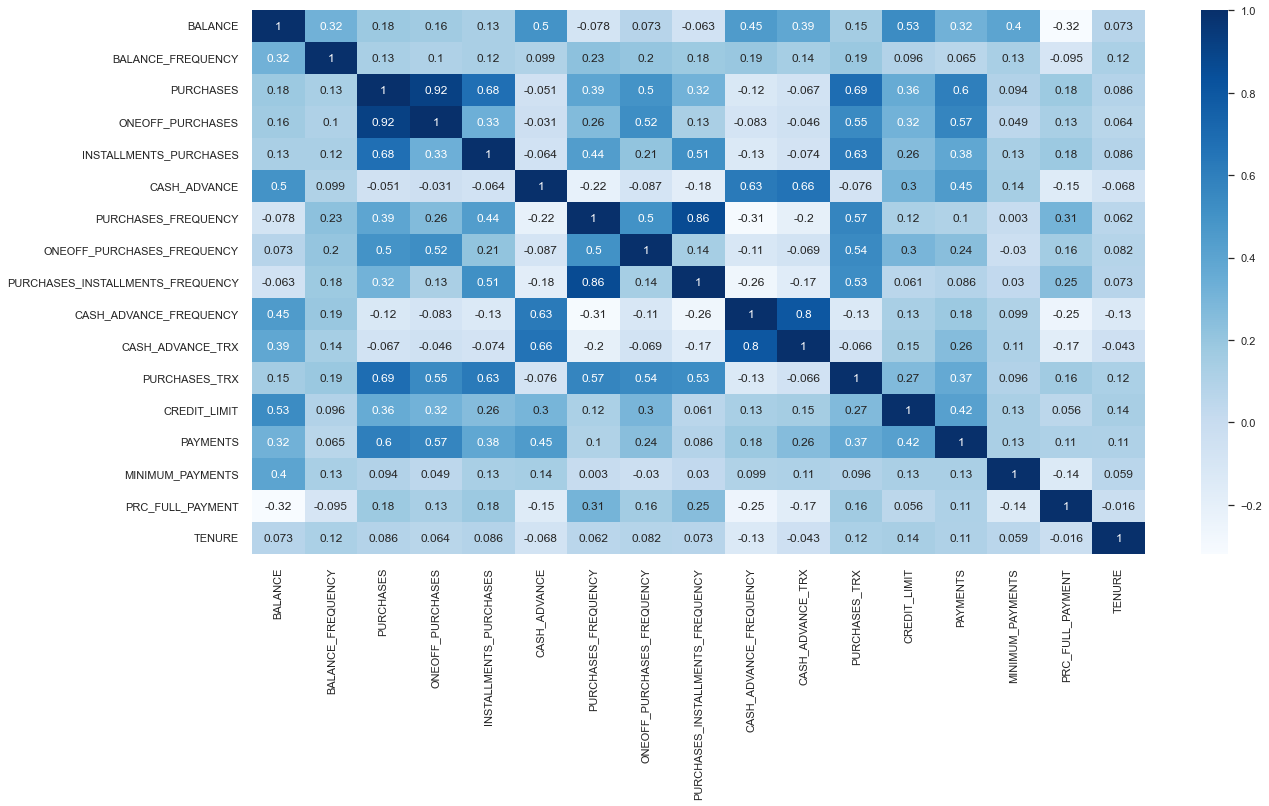

In [ ]:
cor = creditcard_df.corr()
plt.figure(figsize=(20, 10))
sns.set(font_scale=1)
# Escriba la linea que genere el mapa de calor los colores corresponden a plt.cm.Blues


### Tipos de Feature y preprocessing

Identifiquemos los diferentes tipos de características y transformaciones

In [ ]:
creditcard_df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [ ]:
# 1. Elimne la variable "CUST_ID"

# 2. Construya un pipeline para realizar imputacion simple y tranformación en as varaibles numericas

# Aplique esta tranformación a la BD creditcard_df

In [ ]:
from sklearn.impute import SimpleImputer



In [ ]:
transformed_df

,MINIMUM_PAYMENTS,PAYMENTS,TENURE,BALANCE_FREQUENCY,CASH_ADVANCE_TRX,PRC_FULL_PAYMENT,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,ONEOFF_PURCHASES_FREQUENCY,PURCHASES,PURCHASES_FREQUENCY,BALANCE,CREDIT_LIMIT,PURCHASES_INSTALLMENTS_FREQUENCY,INSTALLMENTS_PURCHASES,ONEOFF_PURCHASES,CASH_ADVANCE
0,-3.109675e-01,-0.528979,0.360680,-0.249434,-0.476070,-0.525551,-0.675349,-0.511333,-0.678661,-0.424900,-0.806490,-0.731989,-0.960433,-0.707313,-0.349079,-0.356934,-0.466786
1,8.931021e-02,0.818642,0.360680,0.134325,0.110074,0.234227,0.573963,-0.591796,-0.678661,-0.469552,-1.221758,0.786961,0.688639,-0.916995,-0.454576,-0.356934,2.605605
2,-1.016632e-01,-0.383805,0.360680,0.518084,-0.476070,-0.525551,-0.675349,-0.109020,2.673451,-0.107668,1.269843,0.447135,0.826062,-0.916995,-0.454576,0.108889,-0.466786
3,4.878305e-17,-0.598688,0.360680,-1.016953,-0.329534,-0.525551,-0.258913,-0.551565,-0.399319,0.232058,-1.014125,0.049099,0.826062,-0.916995,-0.454576,0.546189,-0.368653
4,-2.657913e-01,-0.364368,0.360680,0.518084,-0.476070,-0.525551,-0.675349,-0.551565,-0.399319,-0.462063,-1.014125,-0.358775,-0.905464,-0.916995,-0.454576,-0.347294,-0.466786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-3.498541e-01,-0.486217,-4.122768,0.518084,-0.476070,1.183951,-0.675349,-0.350408,-0.678661,-0.333293,1.269843,-0.737950,-0.960433,1.179833,-0.132643,-0.356934,-0.466786
8946,4.878305e-17,-0.503396,-4.122768,0.518084,-0.476070,-0.525551,-0.675349,-0.350408,-0.678661,-0.329136,1.269843,-0.742423,-0.960433,1.179833,-0.122823,-0.356934,-0.466786
8947,-3.354655e-01,-0.570615,-4.122768,-0.185477,-0.476070,0.329200,-0.675349,-0.390639,-0.678661,-0.401965,0.854576,-0.740398,-0.960433,0.760469,-0.294893,-0.356934,-0.466786
8948,-3.469065e-01,-0.580536,-4.122768,-0.185477,-0.182998,0.329200,0.157527,-0.591796,-0.678661,-0.469552,-1.221758,-0.745174,-1.097856,-0.916995,-0.454576,-0.356934,-0.449352


Ahora que hemos transformado los datos, estamos listos para ejecutar K-Means para agrupar a los clientes de tarjetas de crédito.

### Tuniando el hyperparameter `n_clusters`



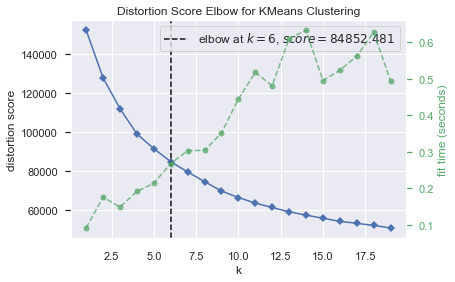

In [ ]:
# Construya un modelo de Kmeans con parametros con defecto


# Visualize el Codo para determinar el número óptimo de clusteres



-A continuación usemos el método de la silueta. Use una semilla igual a 42, realice el gráfico para un numero de clusters igual a 4, 5 y 6.

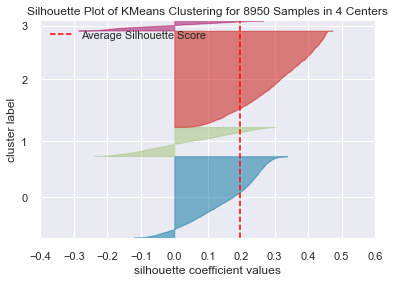

In [ ]:
model = KMeans(4, random_state=42)
visualizer = SilhouetteVisualizer(model, colors="yellowbrick")
visualizer.fit(transformed_df)  # Fit the data to the visualizer
visualizer.show()
# Finalize and render the figure

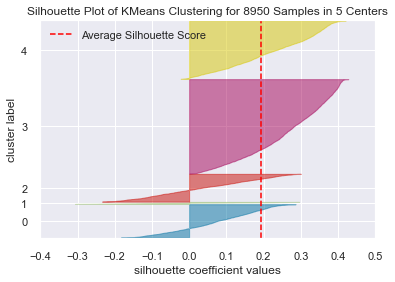

In [ ]:
# Escriba el código para k = 5



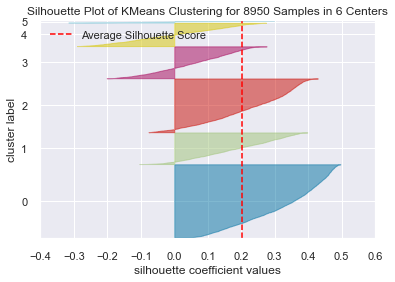

In [ ]:
# Escriba el código para k = 6


In [ ]:
# Obtenga el shape y los lebels para el modelo final elegido con 4 clustes y semilla 123



(4, 17)

- Vamos a visualizar los clusters en dos dimensiones utilizando PCA


In [ ]:
# Obtener los componentes principales


from sklearn.decomposition import PCA


def plot_pca_clusters(data, labels):
    """
    Carries out dimensionality reduction on the data for visualization
    """
    pca = PCA(n_components=2)
    principal_comp = pca.fit_transform(data)
    pca_df = pd.DataFrame(
        data=principal_comp, columns=["pca1", "pca2"], index=data.index
    )
    pca_df["cluster"] = labels
    plt.figure(figsize=(6, 4))
    ax = sns.scatterplot(
        x="pca1", y="pca2", hue="cluster", data=pca_df, palette="tab10"
    )
    plt.show()

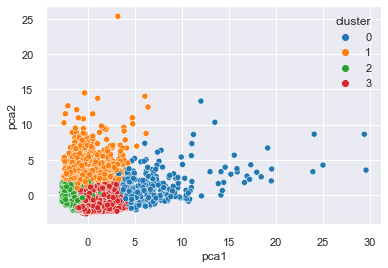

In [ ]:
# Muestre el gráfico para los levels del modelo creado en la linea 85



- Los grupos de arriba parecen razonablemente bien separados.
- No siempre es así !! Recuerde el ejemplo del archivo clustering 1.

### Interpretación de los clusters

- Examinemos los centros de cluster e identifiquemos los tipos de clientes.  

In [ ]:
# Escriba un código que permita visualizar los centroides creados



cluster_centers

,MINIMUM_PAYMENTS,PAYMENTS,TENURE,BALANCE_FREQUENCY,CASH_ADVANCE_TRX,PRC_FULL_PAYMENT,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,ONEOFF_PURCHASES_FREQUENCY,PURCHASES,PURCHASES_FREQUENCY,BALANCE,CREDIT_LIMIT,PURCHASES_INSTALLMENTS_FREQUENCY,INSTALLMENTS_PURCHASES,ONEOFF_PURCHASES,CASH_ADVANCE
0,0.477421,1.919096,0.324140,0.462694,-0.170458,0.454703,-0.319096,3.003251,1.798653,3.125845,1.136338,0.954485,1.429882,1.065918,2.406470,2.713251,-0.155091
1,0.490910,0.603821,-0.097146,0.384753,1.617143,-0.406367,1.745948,-0.283580,-0.212939,-0.234638,-0.504848,1.459578,0.838968,-0.450201,-0.253747,-0.163914,1.688972
2,-0.119249,-0.262060,-0.052972,-0.368944,-0.164607,-0.258866,-0.101500,-0.474987,-0.389437,-0.343190,-0.797823,-0.265552,-0.334417,-0.714246,-0.387798,-0.230500,-0.182691
3,-0.091844,-0.138502,0.057744,0.242574,-0.360303,0.395041,-0.462599,0.296985,0.317153,0.109044,0.983721,-0.321688,-0.077298,0.874138,0.255904,0.000926,-0.366373


- Recordemos que hemos aplicado la imputación y el escalado al conjunto de datos.
- Pero podríamos interpretar mejor estos clusters si los centros están en la escala original.
- Así que vamos a aplicar transformaciones inversas para obtener los valores de los centros de los clusters en la escala original.

In [ ]:
data = (
    preprocessor.named_transformers_["pipeline"]
    .named_steps["standardscaler"]
    .inverse_transform(cluster_centers[numeric_features])
)

In [ ]:
org_cluster_centers = pd.DataFrame(data=data, columns=numeric_features)
org_cluster_centers = org_cluster_centers.reindex(
    sorted(org_cluster_centers.columns), axis=1
)
org_cluster_centers

,BALANCE,BALANCE_FREQUENCY,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,INSTALLMENTS_PURCHASES,MINIMUM_PAYMENTS,ONEOFF_PURCHASES,ONEOFF_PURCHASES_FREQUENCY,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,PURCHASES_TRX,TENURE
0,3551.153761,0.986879,653.638891,0.071290,2.085575,9696.943765,2587.208264,1976.815179,5095.878826,0.739031,7288.739497,0.286707,7681.620098,0.946418,0.788060,89.359413,11.951100
1,4602.462714,0.968415,4520.724309,0.484526,14.284641,7546.957050,181.607404,2008.251157,320.373681,0.138934,3481.145990,0.034859,501.896219,0.287731,0.185516,7.661102,11.387312
2,1011.751528,0.789871,595.759339,0.114833,2.125503,3277.703165,60.386625,586.301239,209.853863,0.086281,974.505090,0.078001,269.973466,0.170146,0.080578,2.903421,11.446429
3,894.907458,0.934734,210.570626,0.042573,0.790021,4213.207678,642.478274,650.167072,593.974874,0.297070,1332.194205,0.269258,1236.178934,0.885165,0.711842,22.091773,11.594595


## Identifique las características mas sobresalientes de cada uno de los grupos.

* Grupo 1
* Grupo 2
* Grupo 3
* Grupo 4